# Project EDA - Sentinel-2 Crop Mapping, Lombardia

Dataset: [Kaggle - Sentinel-2 Image Time Series for Crop Mapping](https://www.kaggle.com/datasets/ignazio/sentinel2-crop-mapping)

Cel tego notebooka na tym etapie:

1. pobrać **mały, bezpieczny podzbiór jednego roku** z obszaru Lombardia (`lombardia3/data2019`),
2. sprawdzić format danych Sentinel-2,
3. policzyć podstawowy balans klas masek,
4. obejrzeć obrazy i maski analogicznie jak w `task1.ipynb`.

Uwaga: pełny dataset Kaggle ma około 63 GB. Dlatego notebook nie pobiera całego datasetu ani całego roku dla wszystkich patchy. Domyślnie pobieramy kilka patchy i kilka dat z jednego roku. To wystarcza do EDA i nie blokuje dysku.


## 1. Konfiguracja pobierania


In [1]:
from pathlib import Path
import sys
import subprocess

DATASET_SLUG = "ignazio/sentinel2-crop-mapping"
LOCAL_ROOT = Path("data/sentinel2-crop-mapping-selected")
AREA = "lombardia3"
YEAR_DIR = "data2019"

# Selected test tiles from lombardia3/tileids/testA.tileids.
# Increase this list later if you want broader EDA.
PATCH_IDS = ["1", "10", "100", "1000", "1001", "1002"]

# A small temporal subset of available 2019 Sentinel-2 dates for these patches.
# The full year has more dates, but these are enough for first EDA and visualization.
DATES = [
    "20190909", "20190914", "20190919", "20190924", "20190929",
    "20191004", "20191009", "20191014", "20191019", "20191024",
    "20191029", "20191103", "20191108", "20191113", "20191118",
    "20191123", "20191128", "20191203",
]

print(f"Dataset: {DATASET_SLUG}")
print(f"Subset: {AREA}/{YEAR_DIR}")
print(f"Patch count: {len(PATCH_IDS)}")
print(f"Date count: {len(DATES)}")


Dataset: ignazio/sentinel2-crop-mapping
Subset: lombardia3/data2019
Patch count: 6
Date count: 18


In [2]:
def ensure_package(import_name, pip_name=None):
    try:
        return __import__(import_name)
    except ImportError:
        pip_name = pip_name or import_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
        return __import__(import_name)

ensure_package("kagglehub")
ensure_package("rasterio")

import kagglehub
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm


## 2. Pobranie klas, masek i kilku obrazów z jednego roku


In [3]:
def download_kaggle_file(relative_path: str) -> Path:
    """Download one file from the Kaggle dataset into LOCAL_ROOT."""
    target = LOCAL_ROOT / relative_path
    if target.exists():
        return target
    downloaded = kagglehub.dataset_download(
        DATASET_SLUG,
        path=relative_path,
        output_dir=str(LOCAL_ROOT),
    )
    return Path(downloaded)

# Small metadata files.
classes_path = download_kaggle_file("lombardia-classes/classes25pc.txt")
tileids_path = download_kaggle_file(f"{AREA}/tileids/testA.tileids")

# Per-patch annual masks and selected time-series images.
downloaded_files = []
missing_files = []
for patch_id in PATCH_IDS:
    rel_mask = f"{AREA}/{YEAR_DIR}/{patch_id}/y.tif"
    try:
        downloaded_files.append(download_kaggle_file(rel_mask))
    except Exception as exc:
        missing_files.append((rel_mask, str(exc).split("\n")[0]))

    for date in DATES:
        rel_img = f"{AREA}/{YEAR_DIR}/{patch_id}/{date}.tif"
        try:
            downloaded_files.append(download_kaggle_file(rel_img))
        except Exception as exc:
            missing_files.append((rel_img, str(exc).split("\n")[0]))

print(f"Downloaded / available files: {len(downloaded_files)}")
print(f"Missing files: {len(missing_files)}")
if missing_files[:5]:
    print("First missing files:")
    for row in missing_files[:5]:
        print(row)

print("Local root:", LOCAL_ROOT.resolve())


  0%|          | 0.00/502 [00:00<?, ?B/s]

100%|██████████| 502/502 [00:00<00:00, 152kB/s]

  0%|          | 0.00/23.5k [00:00<?, ?B/s]

100%|██████████| 23.5k/23.5k [00:00<00:00, 558kB/s]

  0%|          | 0.00/23.8k [00:00<?, ?B/s]

...

  0%|          | 0.00/22.0k [00:00<?, ?B/s]

100%|██████████| 22.0k/22.0k [00:00<00:00, 340kB/s]

  0%|          | 0.00/24.2k [00:00<?, ?B/s]

100%|██████████| 24.2k/24.2k [00:00<00:00, 588kB/s]

Downloaded / available files: 114
Missing files: 0
Local root: /Users/piotrpijanowski/Documents/Studia/Semestr 6/advanced_data_mining/pracownia/assignment_9/data/sentinel2-crop-mapping-selected


In [4]:
def read_tif(path: Path):
    with rasterio.open(path) as src:
        arr = src.read()
        profile = src.profile
    return arr, profile

mask_example, mask_profile = read_tif(LOCAL_ROOT / AREA / YEAR_DIR / PATCH_IDS[0] / "y.tif")
image_example, image_profile = read_tif(LOCAL_ROOT / AREA / YEAR_DIR / PATCH_IDS[0] / f"{DATES[0]}.tif")

print("Mask shape:", mask_example.shape, "dtype:", mask_example.dtype, "min/max:", mask_example.min(), mask_example.max())
print("Image shape:", image_example.shape, "dtype:", image_example.dtype, "min/max:", image_example.min(), image_example.max())
print("Image profile:")
print({k: image_profile[k] for k in ["driver", "dtype", "count", "height", "width"] if k in image_profile})


Mask shape: (1, 48, 48) dtype: uint8 min/max: 2 20
Image shape: (9, 48, 48) dtype: int16 min/max: 160 4331
Image profile:
{'driver': 'GTiff', 'dtype': 'int16', 'count': 9, 'height': 48, 'width': 48}


Interpretacja formatu:

- `y.tif` to maska roczna dla patcha, zwykle o rozmiarze `1 x 48 x 48`,
- `YYYYMMDD.tif` to obraz Sentinel-2 z konkretnej daty, zwykle `9 x 48 x 48`,
- 9 kanałów to pasma spektralne Sentinel-2, a nie zwykłe RGB,
- wartości obrazu są reflektancją zapisaną jako liczby całkowite; zgodnie z loaderem autorów można je skalować przez `1e-4`.


## 3. Klasy i mapowanie etykiet


In [5]:
def parse_classes_file(path: Path) -> pd.DataFrame:
    rows = []
    for line in path.read_text().splitlines():
        parts = line.strip().split("|")
        if len(parts) >= 2:
            rows.append({
                "raw_ids": parts[0],
                "name": parts[1],
                "start": parts[2] if len(parts) > 2 else None,
                "stop": parts[3] if len(parts) > 3 else None,
            })
    df = pd.DataFrame(rows)
    df["class_index"] = range(len(df))
    return df

classes_df = parse_classes_file(classes_path)
classes_df


,raw_ids,name,start,stop,class_index
0,0,Unknown,20180101,20181230,0
1,2,Other cereals,20171109,20180630,1
2,4,Woods and other tree crops,20180225,20181030,2
3,7,Forage,20180130,20180715,3
4,9,Corn,20180424,20180915,4
5,12,Rice,20180508,20180930,5
6,"1,3,5,6,8,10,11,13,14,15,16,20",Unknow cropland,20180201,20181230,6
7,"17,18,19,21",No arable land,20180201,20181230,7


In [6]:
raw_to_group = {}
for _, row in classes_df.iterrows():
    for raw_id in str(row["raw_ids"]).split(","):
        raw_to_group[int(raw_id)] = int(row["class_index"])

group_names = classes_df["name"].tolist()
print(raw_to_group)
print(group_names)

def map_raw_mask_to_group(mask_2d: np.ndarray) -> np.ndarray:
    out = np.zeros_like(mask_2d, dtype=np.int64)
    for raw_id, group_id in raw_to_group.items():
        out[mask_2d == raw_id] = group_id
    return out


{0: 0, 2: 1, 4: 2, 7: 3, 9: 4, 12: 5, 1: 6, 3: 6, 5: 6, 6: 6, 8: 6, 10: 6, 11: 6, 13: 6, 14: 6, 15: 6, 16: 6, 20: 6, 17: 7, 18: 7, 19: 7, 21: 7}
['Unknown', 'Other cereals', 'Woods and other tree crops', 'Forage', 'Corn', 'Rice', 'Unknow cropland', 'No arable land']


## 4. Balans klas w pobranym podzbiorze


In [7]:
mask_rows = []
for patch_id in PATCH_IDS:
    mask_path = LOCAL_ROOT / AREA / YEAR_DIR / patch_id / "y.tif"
    if not mask_path.exists():
        continue
    raw_mask = read_tif(mask_path)[0][0]
    grouped_mask = map_raw_mask_to_group(raw_mask)
    unique, counts = np.unique(grouped_mask, return_counts=True)
    for class_id, count in zip(unique, counts):
        mask_rows.append({
            "patch_id": patch_id,
            "class_index": int(class_id),
            "class_name": group_names[int(class_id)],
            "pixels": int(count),
        })

balance_df = pd.DataFrame(mask_rows)
summary_balance = balance_df.groupby(["class_index", "class_name"], as_index=False)["pixels"].sum()
summary_balance["percent"] = 100 * summary_balance["pixels"] / summary_balance["pixels"].sum()
summary_balance.sort_values("class_index")


,class_index,class_name,pixels,percent
0,1,Other cereals,858,6.206597
1,2,Woods and other tree crops,766,5.541088
2,3,Forage,2794,20.211227
3,4,Corn,3442,24.898727
4,6,Unknow cropland,1144,8.275463
5,7,No arable land,4820,34.866898


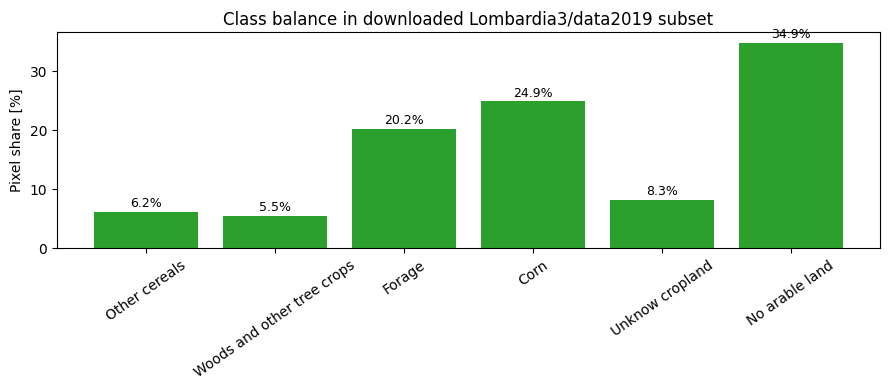

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_df = summary_balance.sort_values("class_index")
ax.bar(plot_df["class_name"], plot_df["percent"], color="tab:green")
ax.set_ylabel("Pixel share [%]")
ax.set_title("Class balance in downloaded Lombardia3/data2019 subset")
ax.tick_params(axis="x", rotation=35)
for i, value in enumerate(plot_df["percent"]):
    ax.text(i, value + 0.3, f"{value:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


## 5. Wizualizacja obrazów Sentinel-2 i masek


In [9]:
# Band order used by the authors' loader/demo for 9-channel IREA Sentinel-2 patches:
# B2, B3, B4, B5, B6, B7, B8, B11, B12
BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B11", "B12"]
BAND_TO_INDEX = {band: i for i, band in enumerate(BANDS)}

# Compact color map for grouped classes.
CLASS_COLORS = np.array([
    [0.00, 0.00, 0.00],  # Unknown
    [0.78, 0.08, 0.52],  # Other cereals
    [0.00, 0.00, 1.00],  # Woods/tree crops
    [0.00, 0.39, 0.00],  # Forage
    [1.00, 1.00, 0.00],  # Corn
    [0.25, 0.88, 0.82],  # Rice
    [0.55, 0.55, 0.55],  # Unknown cropland
    [0.98, 0.67, 0.12],  # No arable land
])
class_cmap = ListedColormap(CLASS_COLORS[:len(group_names)])
class_norm = BoundaryNorm(np.arange(len(group_names) + 1) - 0.5, class_cmap.N)

def percentile_stretch(img, low=2, high=98):
    img = img.astype(np.float32)
    out = np.zeros_like(img, dtype=np.float32)
    for c in range(img.shape[0]):
        lo, hi = np.percentile(img[c], [low, high])
        out[c] = np.clip((img[c] - lo) / (hi - lo + 1e-6), 0, 1)
    return out

def make_rgb(s2_image):
    # True color: RGB = B4, B3, B2.
    rgb = s2_image[[BAND_TO_INDEX["B4"], BAND_TO_INDEX["B3"], BAND_TO_INDEX["B2"]]]
    return percentile_stretch(rgb).transpose(1, 2, 0)

def make_false_color(s2_image):
    # False color: NIR, red, green = B8, B4, B3.
    rgb = s2_image[[BAND_TO_INDEX["B8"], BAND_TO_INDEX["B4"], BAND_TO_INDEX["B3"]]]
    return percentile_stretch(rgb).transpose(1, 2, 0)

def compute_ndvi(s2_image):
    red = s2_image[BAND_TO_INDEX["B4"]].astype(np.float32)
    nir = s2_image[BAND_TO_INDEX["B8"]].astype(np.float32)
    return (nir - red) / (nir + red + 1e-6)


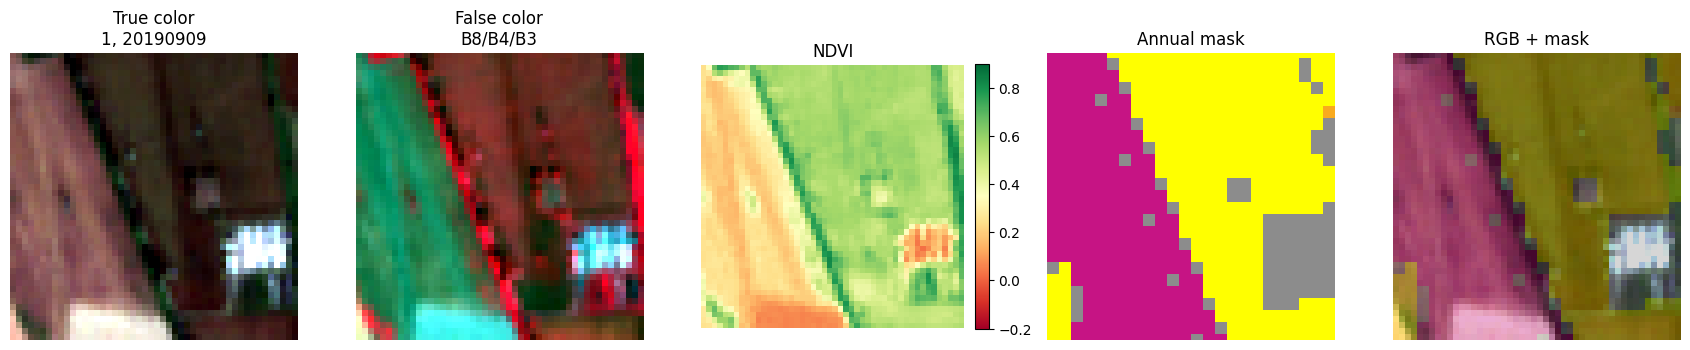

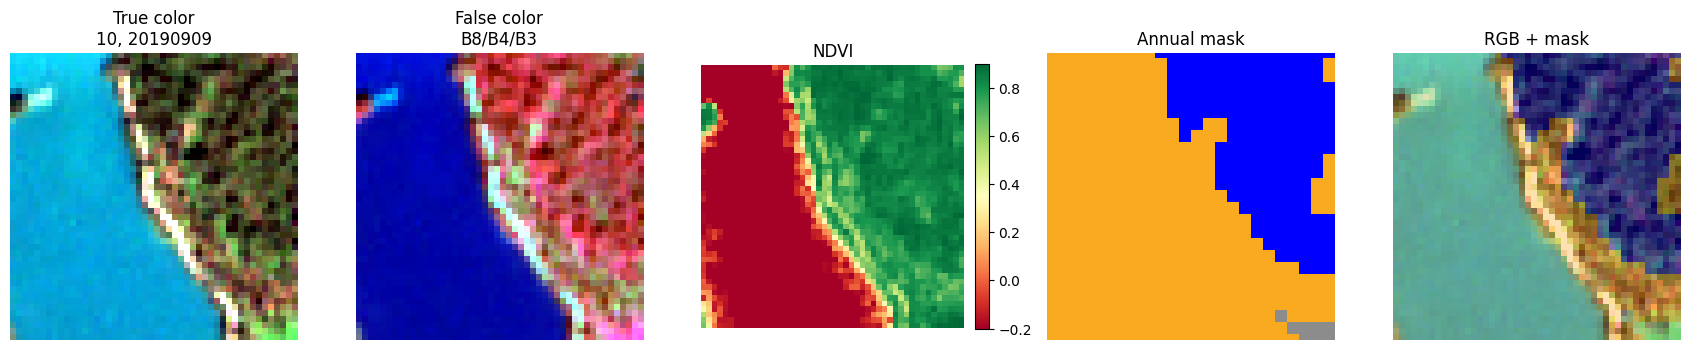

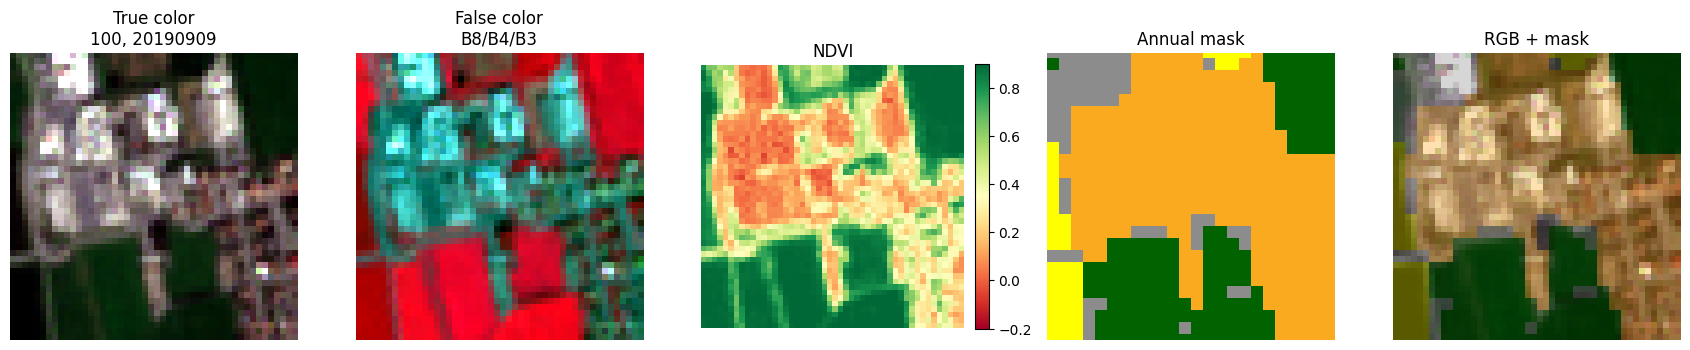

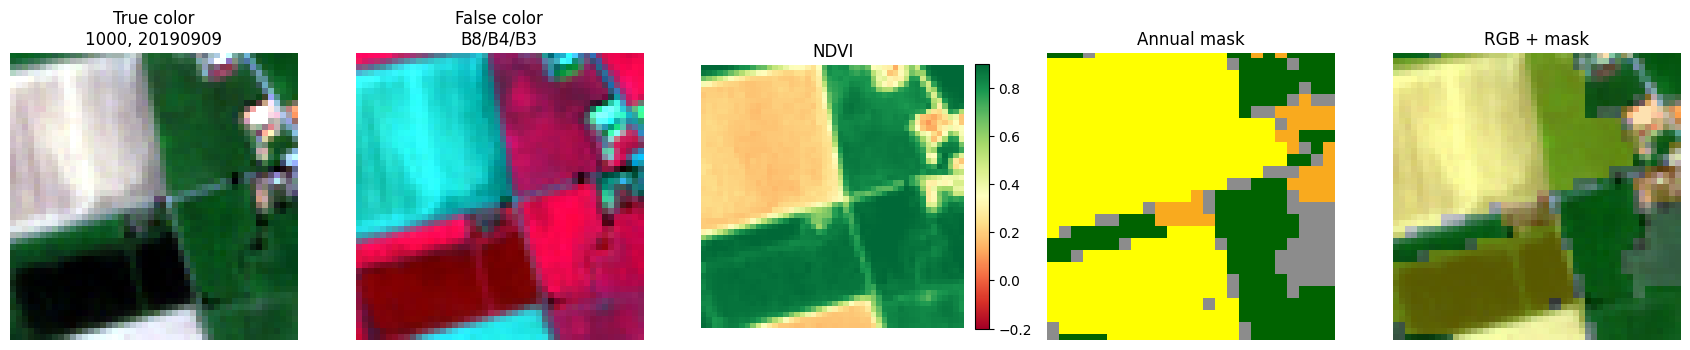

In [10]:
def show_patch_example(patch_id: str, date: str):
    img_path = LOCAL_ROOT / AREA / YEAR_DIR / patch_id / f"{date}.tif"
    mask_path = LOCAL_ROOT / AREA / YEAR_DIR / patch_id / "y.tif"
    s2 = read_tif(img_path)[0]
    raw_mask = read_tif(mask_path)[0][0]
    grouped_mask = map_raw_mask_to_group(raw_mask)

    true_rgb = make_rgb(s2)
    false_rgb = make_false_color(s2)
    ndvi = compute_ndvi(s2)
    mask_rgb = CLASS_COLORS[grouped_mask]
    overlay = np.clip(0.65 * true_rgb + 0.35 * mask_rgb, 0, 1)

    fig, axes = plt.subplots(1, 5, figsize=(17, 3.6))
    axes[0].imshow(true_rgb)
    axes[0].set_title(f"True color\n{patch_id}, {date}")
    axes[1].imshow(false_rgb)
    axes[1].set_title("False color\nB8/B4/B3")
    im = axes[2].imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.9)
    axes[2].set_title("NDVI")
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    axes[3].imshow(grouped_mask, cmap=class_cmap, norm=class_norm)
    axes[3].set_title("Annual mask")
    axes[4].imshow(overlay)
    axes[4].set_title("RGB + mask")

    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

for patch_id in PATCH_IDS[:4]:
    show_patch_example(patch_id, DATES[0])


## 6. Zmienność czasowa jednej próbki


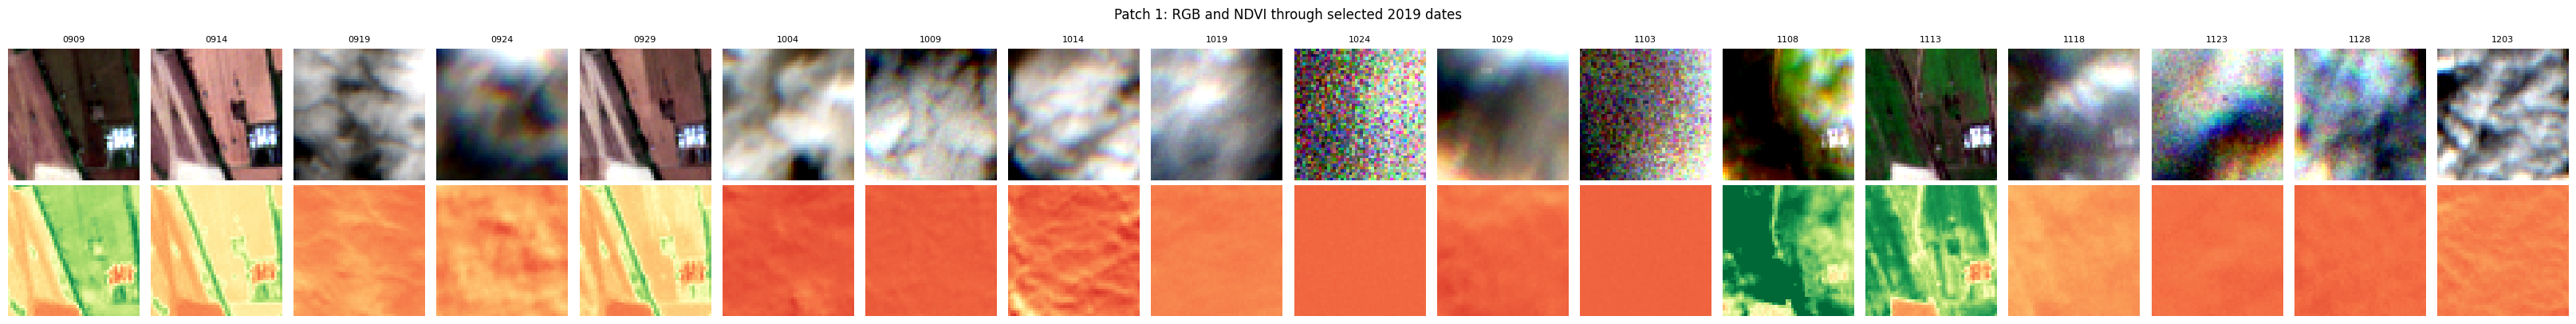

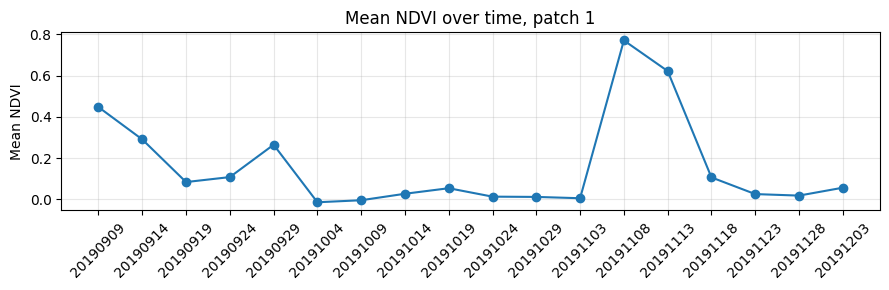

In [11]:
def plot_temporal_sequence(patch_id: str, dates: list[str]):
    available_dates = [d for d in dates if (LOCAL_ROOT / AREA / YEAR_DIR / patch_id / f"{d}.tif").exists()]
    n = len(available_dates)
    fig, axes = plt.subplots(2, n, figsize=(1.8 * n, 4.2))
    if n == 1:
        axes = axes.reshape(2, 1)

    mean_ndvi = []
    for i, date in enumerate(available_dates):
        s2 = read_tif(LOCAL_ROOT / AREA / YEAR_DIR / patch_id / f"{date}.tif")[0]
        axes[0, i].imshow(make_rgb(s2))
        axes[0, i].set_title(date[4:], fontsize=8)
        axes[0, i].axis("off")
        ndvi = compute_ndvi(s2)
        mean_ndvi.append(float(np.nanmean(ndvi)))
        axes[1, i].imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.9)
        axes[1, i].axis("off")

    fig.suptitle(f"Patch {patch_id}: RGB and NDVI through selected 2019 dates")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(available_dates, mean_ndvi, marker="o")
    ax.set_title(f"Mean NDVI over time, patch {patch_id}")
    ax.set_ylabel("Mean NDVI")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_temporal_sequence(PATCH_IDS[0], DATES)


## Wnioski z pierwszego EDA

- Dane są dużo bardziej złożone niż w `task1.ipynb`: pojedynczy obraz ma 9 kanałów spektralnych, a dla patcha mamy wiele dat w roku.
- Maska `y.tif` jest maską roczną, natomiast obrazy `YYYYMMDD.tif` tworzą serię czasową.
- Do prostego modelu segmentacyjnego można użyć pojedynczej daty jako wejścia `9 x 48 x 48`, ale bardziej naturalne jest użycie całej sekwencji `T x 9 x 48 x 48` albo kilku dat sklejonych kanałowo.
- Balans klas trzeba liczyć na większej liczbie patchy przed treningiem, bo mały podzbiór EDA może nie pokazywać pełnego rozkładu klas.
